In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

PHYSIOLOGICAL

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving physiological_signals_60sn.csv to physiological_signals_60sn.csv


In [ ]:
import pandas as pd

# Load the physiological data
path = 'physiological_signals_60sn.csv'
df = pd.read_csv(path)

# Show the first few rows
df.head()

,eda,bvp,temp,x,y,z,emotion
0,0.00,-0.03,31.63,-13,-18,62,0
1,0.04,5.06,31.63,-15,-18,62,0
2,0.08,17.91,31.63,-14,-17,62,0
3,0.08,79.34,31.63,-16,-17,60,0
4,0.08,228.25,31.63,3,-12,63,0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import BatchNormalization
from keras.callbacks import ReduceLROnPlateau



# Load physiological data
physio_df = pd.read_csv("physiological_signals_60sn.csv")

# Convert emotion column to binary: 2 (stress) -> 1
physio_df['emotion'] = physio_df['emotion'].replace({2: 1})

# Feature and label selection
X = physio_df[['eda', 'bvp', 'temp', 'x', 'y', 'z']].values
y = physio_df['emotion'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Define better model
model = Sequential([
    Dense(128, activation='relu', input_shape=(6,)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {acc:.4f}")

# Classification report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
3360/3360 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.6336 - loss: 0.6690 - val_accuracy: 0.6920 - val_loss: 0.5964 - learning_rate: 0.0010
Epoch 2/100
3360/3360 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6813 - loss: 0.6076 - val_accuracy: 0.7134 - val_loss: 0.5663 - learning_rate: 0.0010
Epoch 3/100
3360/3360 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7004 - loss: 0.5865 - val_accuracy: 0.7284 - val_loss: 0.5455 - learning_rate: 0.0010
Epoch 4/100
3360/3360 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7113 - loss: 0.5703 - val_accuracy: 0.7368 - val_loss: 0.5290 - learning_rate: 0.0010
Epoch 5/100
3360/3360 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7194 - loss: 0.5621 - val_accuracy: 0.7490 - val_loss: 0.5173 - learning_rate: 0.0010
Epoch 6/100
3360/3360 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7230 - loss: 0.5530 - val_accuracy: 0.7584 - val_loss: 0.5083 - learning_rate: 0.0010
Epoch 7/100
3360/3360 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accura

In [ ]:
physio_model = model  # replace with actual variable name
physio_model.save('/content/models/physio_model.h5')
print("✅ Physiological model saved.")

✅ Physiological model saved.


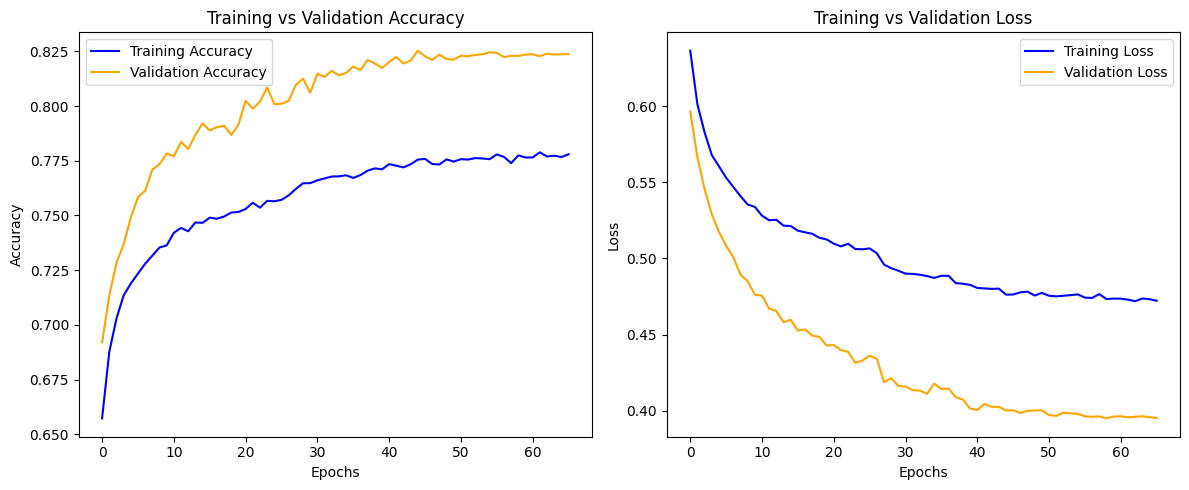

In [ ]:
# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Select one row from the original (unscaled) dataset
sample_row = physio_df.iloc[0][['eda', 'bvp', 'temp', 'x', 'y', 'z']].values.reshape(1, -1)

# Scale it using the same scaler used during training
sample_row_scaled = scaler.transform(sample_row)

# Predict the probability and class
prediction_prob = model.predict(sample_row_scaled)
prediction_class = (prediction_prob > 0.5).astype("int32")

print("Input features:", sample_row)
print("Scaled input:", sample_row_scaled)
print("Predicted probability of stress:", prediction_prob[0][0])
print("Predicted class (0 = no stress, 1 = stress):", prediction_class[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
Input features: [[ 0.000e+00 -3.000e-02  3.163e+01 -1.300e+01 -1.800e+01  6.200e+01]]
Scaled input: [[-0.45259697 -0.0016007  -1.0296648  -0.7840736  -0.65699378  1.28324782]]
Predicted probability of stress: 0.022445446
Predicted class (0 = no stress, 1 = stress): 0


FACIAL

In [ ]:
from google.colab import files
uploaded = files.upload()

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


344/344 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.5711 - loss: 0.6783 - val_accuracy: 0.6511 - val_loss: 0.6501
Epoch 2/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.6198 - loss: 0.6506 - val_accuracy: 0.6822 - val_loss: 0.5959
Epoch 3/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.6584 - loss: 0.6163 - val_accuracy: 0.7236 - val_loss: 0.5474
Epoch 4/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.6836 - loss: 0.5939 - val_accuracy: 0.7539 - val_loss: 0.5068
Epoch 5/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7021 - loss: 0.5749 - val_accuracy: 0.7719 - val_loss: 0.4879
Epoch 6/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7173 - loss: 0.5474 - val_accuracy: 0.7740 - val_loss: 0.4714
Epoch 7/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7347 - loss: 0.5300 - val_accuracy: 0.7506 - val_loss: 0.5029
Epoch 8/50
344/344 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7422 - loss: 0.5194 - val_accurac

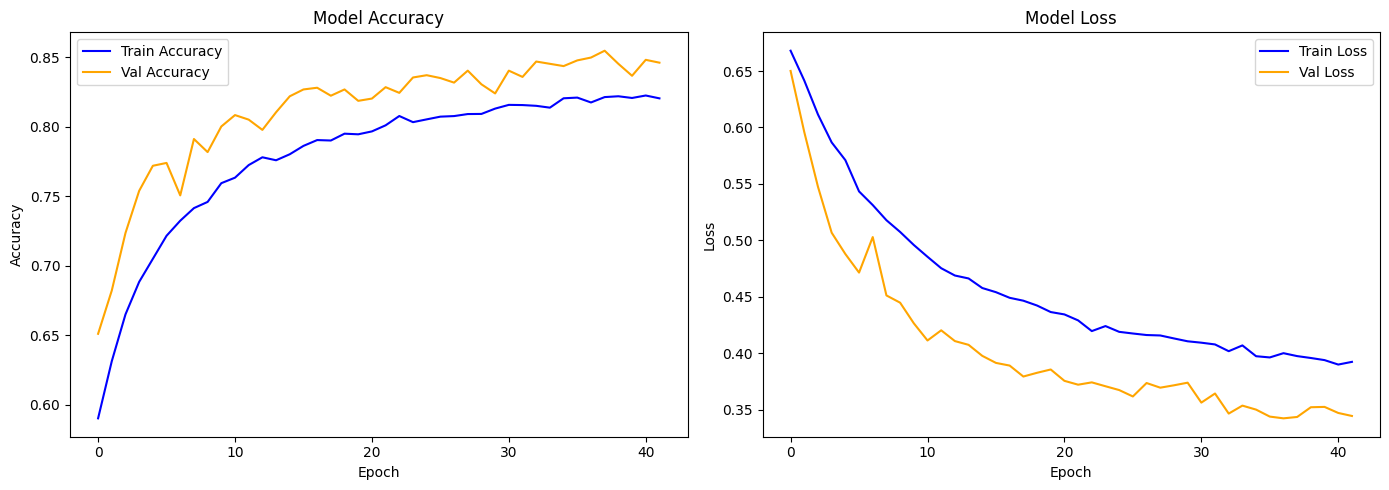

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


df = pd.read_csv("facial_dataset_2_class.csv")

# Convert pixel strings to numpy arrays
X = df['pixels'].apply(lambda x: np.fromstring(x, sep=' '))
X = np.stack(X.values).reshape(-1, 48, 48, 1) / 255.0  # Normalize

# Convert labels
y = to_categorical(df['emotion'].values, num_classes=2)

# Train-test split (we will later split train into train+val manually)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Further split training set into train + validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train, random_state=42)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train_sub)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# CNN model
model = Sequential([
    Input(shape=(48, 48, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model with augmented data
history = model.fit(
    datagen.flow(X_train_sub, y_train_sub, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n✅ CNN Facial Model Accuracy on Test Data: {test_acc:.4f}")

# Plot Accuracy and Loss
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], 'orange', label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-', label='Train Loss')
plt.plot(history.history['val_loss'], 'orange', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
facial_model = model

In [ ]:
# After training the facial CNN model
facial_model.save('/content/models/facial_model.h5')
print("✅ Facial model saved.")

✅ Facial model saved.


In [ ]:
model = tf.keras.models.load_model('/content/models/facial_model.h5')

In [ ]:
!pip install opencv-python-headless

import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from IPython.display import display, Image, clear_output
from PIL import Image as PILImage
import matplotlib.pyplot as plt

In [ ]:
model = load_model('/content/models/facial_model.h5')
print("✅ Model loaded successfully.")

✅ Model loaded successfully.


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from IPython.display import Image
import cv2
import numpy as np
import PIL.Image
import io

# JS to take a photo
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Resize video
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            const dataUrl = canvas.toDataURL('image/jpeg', quality);
            return dataUrl;
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = io.BytesIO(base64.b64decode(data.split(',')[1]))
    img = PIL.Image.open(binary)
    img.save(filename)
    return filename

import base64

# Capture image
photo_path = take_photo()
print(f"Saved to {photo_path}")


<IPython.core.display.Javascript object>

Saved to photo.jpg


In [ ]:
# Load model
import tensorflow as tf
model = tf.keras.models.load_model('/content/models/facial_model.h5')
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Load image
img = cv2.imread(photo_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
resized = cv2.resize(gray, (48, 48))
normalized = resized / 255.0
input_img = normalized.reshape(1, 48, 48, 1)

# Predict
prediction = model.predict(input_img, verbose=0)
class_id = np.argmax(prediction)
confidence = prediction[0][class_id]
label = "Stressed" if class_id == 1 else "Not Stressed"

print(f"🧠 Prediction: {label} (Confidence: {confidence:.2f})")


🧠 Prediction: Stressed (Confidence: 0.57)


SURVEY

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving instantQuestionnaires-HLlouH.csv to instantQuestionnaires-HLlouH.csv


In [ ]:
import pandas as pd

# Replace with the exact name of the uploaded file
df = pd.read_csv("instantQuestionnaires-HLlouH.csv")

# Check columns
print("Total columns:", len(df.columns))
print("Columns:", df.columns.tolist())

Total columns: 7
Columns: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'Date']


In [ ]:
high_stress = ['Tension', 'Unhappy', 'Bad', 'Angry', 'Anxious', 'Sad', 'Guilty', 'Sick']
low_stress = ['Pleased', 'Comfortable', 'Good', 'Happy', 'Excited', 'Energetic', 'Neutral']

df['stress_label'] = df['C1'].apply(lambda x: 1 if x in high_stress else (0 if x in low_stress else np.nan))
df = df.dropna(subset=['stress_label'])  # remove undefined labels

X = df[['C2', 'C3', 'C4', 'C5', 'C6']]
y = df['stress_label'].astype(int)


In [ ]:
import pandas as pd
import numpy as np

# Load dataset (update path if needed)
df = pd.read_csv("instantQuestionnaires-HLlouH.csv")

# Define high and low stress categories
high_stress = ['Tension', 'Unhappy', 'Bad', 'Angry', 'Anxious', 'Sad', 'Guilty', 'Sick']
low_stress = ['Pleased', 'Comfortable', 'Good', 'Happy', 'Excited', 'Energetic', 'Neutral']

# Map labels to binary stress values
df['stress_label'] = df['C1'].apply(lambda x: 1 if x in high_stress else (0 if x in low_stress else np.nan))

# Drop rows with undefined stress labels
df = df.dropna(subset=['stress_label'])

# Convert to int
df['stress_label'] = df['stress_label'].astype(int)


In [ ]:
from sklearn.preprocessing import OneHotEncoder

features = ['C2', 'C3', 'C4', 'C5', 'C6']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


X_encoded = encoder.fit_transform(df[features])
y = df['stress_label'].values


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# CNN needs 3D shape: (samples, timesteps, features)
X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),  # ⬅️ this helps prevent overfitting
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # ⬅️ binary output
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]  # ⬅️ added here
)



Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.6545 - loss: 0.6284 - val_accuracy: 0.7983 - val_loss: 0.4397
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8229 - loss: 0.4566 - val_accuracy: 0.8908 - val_loss: 0.3252
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8638 - loss: 0.3538 - val_accuracy: 0.8739 - val_loss: 0.2846
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8680 - loss: 0.3340 - val_accuracy: 0.8992 - val_loss: 0.2836
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8672 - loss: 0.3110 - val_accuracy: 0.8655 - val_loss: 0.2848
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8766 - loss: 0.3014 - val_accuracy: 0.9076 - val_loss: 0.2802
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9001 - loss: 0.2977 - val_accuracy: 0.8824 - val_loss: 0.2661
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8989 - loss: 0.2723 - val_accuracy: 0.9076 - val

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9005 - loss: 0.2683 
Test Accuracy: 0.91


In [ ]:
survey_model = model  # replace with correct variable
survey_model.save('/content/models/survey_model.h5')
print("✅ Survey model saved.")

✅ Survey model saved.


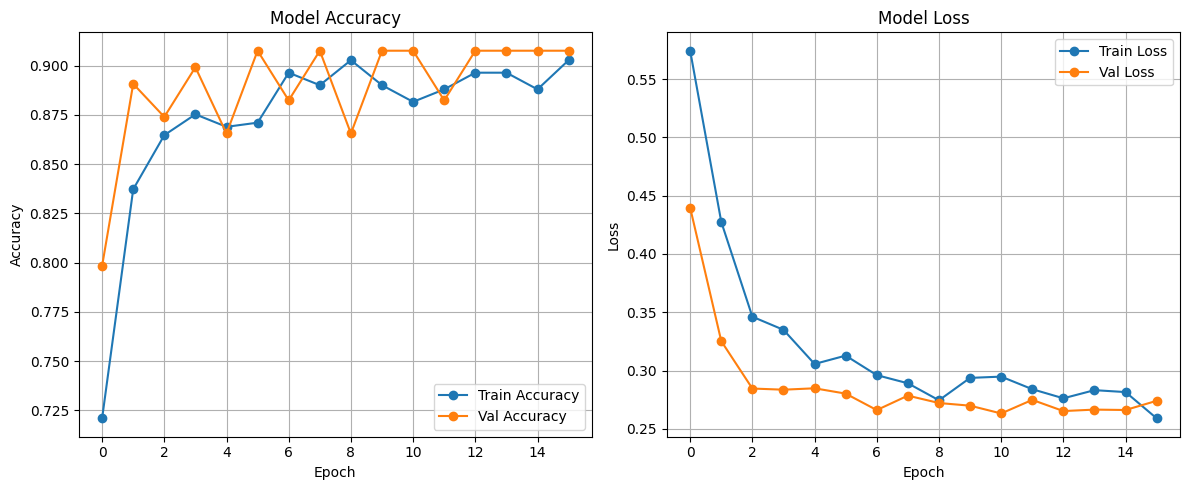

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Step 1: Load dataset (from the CSV you used to train)
df = pd.read_csv("/content/instantQuestionnaires-HLlouH.csv")

# Step 2: Filter and label stress levels
high_stress = ['Tension', 'Unhappy', 'Bad', 'Angry', 'Anxious', 'Sad', 'Guilty', 'Sick']
low_stress = ['Pleased', 'Comfortable', 'Good', 'Happy', 'Excited', 'Energetic', 'Neutral']
df['stress_label'] = df['C1'].apply(lambda x: 1 if x in high_stress else (0 if x in low_stress else np.nan))
df = df.dropna(subset=['stress_label'])
df['stress_label'] = df['stress_label'].astype(int)

# Step 3: Encode & scale features
features = ['C2', 'C3', 'C4', 'C5', 'C6']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(df[features])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Step 4: Load your trained model (must already exist in this path)
model = tf.keras.models.load_model("/content/models/survey_model.h5")  # ✅ Correct


# Step 5: Define prediction function for Gradio
# Global variables to hold the prediction
survey_output = None
survey_confidence = None

def predict_stress(activity, companion, pressure, tired, energetic):
    global survey_output, survey_confidence

    user_input = pd.DataFrame([{
        'C2': activity,
        'C3': companion,
        'C4': pressure,
        'C5': tired,
        'C6': energetic
    }])

    encoded = encoder.transform(user_input[features])
    scaled = scaler.transform(encoded)
    ready = scaled.reshape(1, scaled.shape[1], 1)

    prediction = model.predict(ready)[0][0]
    label = "🧠 Stressed" if prediction >= 0.5 else "🙂 Not Stressed"

    confidence = prediction if prediction >= 0.5 else 1 - prediction

    # ✅ Store results in global variables
    survey_output = int(prediction >= 0.5)
    survey_confidence = float(confidence)

    return f"{label} (Confidence: {confidence:.2f})"


# Step 6: Create Gradio interface
gr.Interface(
    fn=predict_stress,
    inputs=[
        gr.Radio(sorted(df["C2"].dropna().unique()), label="What activity are you currently engaged in?"),
        gr.Radio(sorted(df["C3"].dropna().unique()), label="Who are you currently with?"),
        gr.Radio(sorted(df["C4"].dropna().unique()), label="Do you feel under pressure right now?"),
        gr.Radio(sorted(df["C5"].dropna().unique()), label="Do you feel tired?"),
        gr.Radio(sorted(df["C6"].dropna().unique()), label="Do you feel energetic right now?")
    ],
    outputs="text",
    title="📝 Stress Questionnaire",
    description="Answer these questions to assess your stress level"
).launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ea2d43b8829c02736c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
print("Output:", survey_output)
print("Confidence:", survey_confidence)


Output: 1
Confidence: 0.890545666217804


AUDIO

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import zipfile
import os

# Path to your uploaded zip file
zip_path = "/content/ravdess.zip"  # change this if your file name is different

# Destination folder
extract_to = "/content/ravdess_audio"

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"✅ Extracted RAVDESS to: {extract_to}")

In [ ]:
data_dir = "/content/ravdess"
print("✅ Extracted files to:", data_dir)

In [ ]:
import os
data_dir = "/content/ravdess_audio"  # or whatever the correct path is after unzip

In [ ]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [ ]:
print(os.listdir(data_dir))

In [ ]:
import librosa
import numpy as np

X, y = [], []

for root, _, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".wav"):
            path = os.path.join(root, file)
            try:
                audio, sr = librosa.load(path, sr=22050)
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                mfcc = np.pad(mfcc, ((0, 0), (0, max(0, 100 - mfcc.shape[1]))), mode='constant')[:, :100]
                X.append(mfcc)

                emotion_id = file.split("-")[2]  # Extract emotion code
                y.append(emotion_map[emotion_id])
            except Exception as e:
                print(f"❌ Failed on {file}: {e}")

X = np.array(X)[..., np.newaxis]
print("✅ Data shape:", X.shape)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)
print("✅ Encoded labels:", le.classes_)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(40, 100, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='softmax')  # 8 emotions
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_test, y_test))

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {acc*100:.2f}%")

In [ ]:
audio_model = model  # replace if you used a different variable
audio_model.save('/content/models/audio_model.h5')
print("✅ Audio model saved.")

In [ ]:
!pip install pipwin
!pipwin install pyaudio

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import numpy as np
import librosa
import tensorflow as tf
import soundfile as sf  # Ensure this is installed

# 🔁 Load your trained audio model
model = tf.keras.models.load_model('/content/models/audio_model.h5')
label_map = ["No Stress", "Low Stress", "Moderate Stress", "High Stress"]

# 🎯 Extract MFCC Features
def extract_features(audio, sr=22050):
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=38)
    if mfccs.shape[1] < 98:
        pad_width = 98 - mfccs.shape[1]
        mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfccs = mfccs[:, :98]

    mfccs = np.expand_dims(mfccs, axis=-1)  # shape: (38, 98, 1)
    return mfccs
# Global variable to hold output
last_audio_output = ""

def predict_stress_and_store(audio_file):
    global last_audio_output
    try:
        y, sr = librosa.load(audio_file, sr=22050)
        features = extract_features(y, sr)
        features = features.reshape(1, 38, 98, 1)

        prediction = model.predict(features)
        confidence = float(np.max(prediction))
        label_index = int(np.argmax(prediction))
        label = label_map[label_index]

        result = f"{label} ({confidence*100:.2f}%)"
        last_audio_output = result
        return f"🧠 Predicted: {label}\n🔒 Confidence: {confidence*100:.2f}%"
    except Exception as e:
        return f"❌ Error: {str(e)}"

# Gradio Interface
interface = gr.Interface(
    fn=predict_stress_and_store,
    inputs=gr.Audio(type="filepath", label="🎙️ Record your voice"),
    outputs="text",
    live=False
)

interface.launch()

# # 🔍 Stress Prediction
# #def predict_stress(audio_file):
#     try:
#         y, sr = librosa.load(audio_file, sr=22050)
#         features = extract_features(y, sr)
#         features = features.reshape(1, 38, 98, 1)  # Shape for model

#         prediction = model.predict(features)
#         confidence = float(np.max(prediction))
#         label_index = int(np.argmax(prediction))
#         label = label_map[label_index]

#         return f"🧠 Predicted: {label}\n🔒 Confidence: {confidence*100:.2f}%"

#     except Exception as e:
#         return f"❌ Error: {str(e)}"

# 🧠 Gradio UI
interface = gr.Interface(
    fn=predict_stress,
    inputs=gr.Audio(type="filepath", label="🎙️ Record your voice"),
    outputs="text",
    title="Real-Time Stress Detection from Voice",
    description="Speak naturally and let the model assess your stress level.",
    live=False
)

interface.launch(debug=True)